# Week 2 — Statistical Anomaly Detection

**Goal:** Flag anomalous demand days per product category using three
complementary methods — **Z-Score**, **IQR**, and **Isolation Forest** — then
combine them into a single consensus flag.

> We detect on the **residual** (demand minus trend & weekly seasonality) for
> the univariate methods, so normal seasonal peaks aren't mistaken for
> anomalies. `Clothing` has the most interpolated days of any category (see
> Week 1), so treat its flags with extra caution.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DAILY_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'
OUT_PATH = Path('..') / 'data' / 'processed' / 'anomalies.csv'

NUM_COLS = ['units_sold', 'inventory_level', 'unit_price', 'warehouse_dispatch_rate']
TARGET = 'units_sold'
SAMPLE_CAT = 'Electronics'

daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)
print('Loaded shape:', daily.shape)
print('Categories:', daily['product_category'].nunique())

Loaded shape: (12200, 7)
Categories: 11


## 1. Deseasonalize: compute the residual per category

Decompose each category's `units_sold` (additive, weekly period) and keep the
**residual** = demand with trend and weekly seasonality removed. Anomalies are
the residual values that stand out from the rest.

In [2]:
def add_residual(frame):
    """Add a 'residual' column (units_sold minus trend & weekly seasonality) per category."""
    parts = []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.sort_values('date').copy()
        result = seasonal_decompose(sub.set_index('date')[TARGET], model='additive', period=7)
        sub['residual'] = result.resid.values
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)

work = add_residual(daily)
print('Rows with a residual:', work['residual'].notna().sum(), '/', len(work))

Rows with a residual: 12134 / 12200


## 2. Z-Score method

Within each category, standardize the residual and flag any day whose absolute
z-score exceeds **3** (roughly beyond 3 standard deviations).

In [3]:
Z_THRESH = 3.0

def zscore(s):
    std = s.std(ddof=0)
    return (s - s.mean()) / std if std else s * 0

work['z'] = work.groupby('product_category')['residual'].transform(zscore)
work['anomaly_z'] = work['z'].abs() > Z_THRESH
print('Z-Score anomalies:', int(work['anomaly_z'].sum()))
work.loc[work['anomaly_z'], ['date', 'product_category', 'units_sold', 'residual', 'z']].head()

Z-Score anomalies: 153


,date,product_category,units_sold,residual,z
221,2020-08-09,Apparel,1007.600000,505.937168,4.109438
295,2020-10-22,Apparel,1614.300000,677.956025,5.506583
317,2020-11-13,Apparel,493.900000,-393.754363,-3.197895
319,2020-11-15,Apparel,1417.166667,443.482406,3.602178
320,2020-11-16,Apparel,1878.800000,905.650132,7.355924


## 3. IQR method (Tukey fences)

Flag residuals that fall below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`. More robust to extreme values than the z-score, so it typically flags a wider set of borderline days.

In [4]:
IQR_K = 1.5

def iqr_flag(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - IQR_K * iqr) | (s > q3 + IQR_K * iqr)

work['anomaly_iqr'] = work.groupby('product_category')['residual'].transform(iqr_flag).fillna(False)
print('IQR anomalies:', int(work['anomaly_iqr'].sum()))
work.loc[work['anomaly_iqr'], ['date', 'product_category', 'units_sold', 'residual']].head()

IQR anomalies: 1238


,date,product_category,units_sold,residual
3,2020-01-04,Apparel,600.6,132.692232
23,2020-01-24,Apparel,737.4,246.554208
46,2020-02-16,Apparel,632.5,192.458596
68,2020-03-09,Apparel,340.3,-80.364154
127,2020-05-07,Apparel,665.8,222.161739


## 4. Isolation Forest (multivariate)

Unlike the two univariate methods above, Isolation Forest looks at all numeric
features together (`units_sold, inventory_level, unit_price,
warehouse_dispatch_rate`), so it can catch unusual **combinations** of values.
One model per category, `contamination=0.02` (assume ~2% of days are
anomalous).

In [5]:
CONTAMINATION = 0.02

def iforest_flag(frame):
    parts = []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.copy()
        model = IsolationForest(contamination=CONTAMINATION, random_state=42)
        sub['anomaly_if'] = model.fit_predict(sub[NUM_COLS]) == -1
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)

work = iforest_flag(work)
print('Isolation Forest anomalies:', int(work['anomaly_if'].sum()))

Isolation Forest anomalies: 245


## 5. Consensus vote & per-category summary

Combine the three methods. A day is a **consensus anomaly** when at least
**2 of 3** methods agree — this filters out one-off flags and keeps the
anomalies we're most confident about.

In [6]:
flag_cols = ['anomaly_z', 'anomaly_iqr', 'anomaly_if']
work['anomaly_votes'] = work[flag_cols].sum(axis=1)
work['anomaly_consensus'] = work['anomaly_votes'] >= 2

summary = (work.groupby('product_category')[flag_cols + ['anomaly_consensus']]
               .sum().astype(int)
               .rename(columns={'anomaly_z': 'z', 'anomaly_iqr': 'iqr',
                                 'anomaly_if': 'iforest', 'anomaly_consensus': 'consensus'}))
summary['days'] = work.groupby('product_category').size()
print('Total consensus anomalies:', int(work['anomaly_consensus'].sum()))
summary

Total consensus anomalies: 193


,z,iqr,iforest,consensus,days
product_category,,,,,
Apparel,16,106,22,18,1100
Automotive Parts,15,102,24,19,1186
Beauty,15,113,22,18,1098
Clothing,13,151,22,21,1091
Electronics,15,124,22,19,1100
Furniture,10,119,22,11,1100
Groceries,15,109,22,19,1099
Office Supplies,10,102,22,14,1100
Pet Supplies,11,97,22,14,1100


## 6. Visualize each method for one category

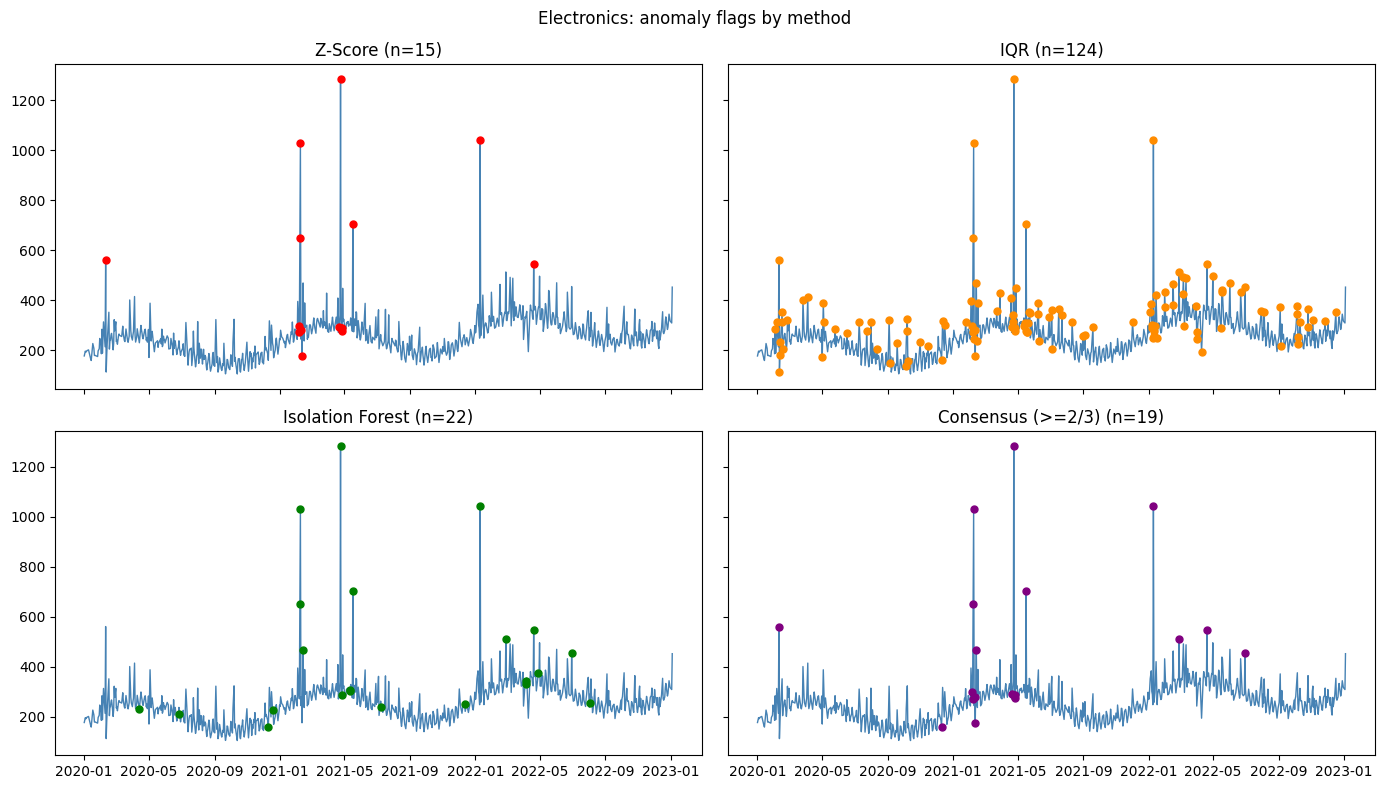

In [7]:
sub = work[work['product_category'] == SAMPLE_CAT].sort_values('date')

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
methods = [('anomaly_z', 'red', 'Z-Score'), ('anomaly_iqr', 'darkorange', 'IQR'),
           ('anomaly_if', 'green', 'Isolation Forest'), ('anomaly_consensus', 'purple', 'Consensus (>=2/3)')]
for ax, (col, color, label) in zip(axes.flat, methods):
    hits = sub[sub[col]]
    ax.plot(sub['date'], sub['units_sold'], color='steelblue', lw=1)
    ax.scatter(hits['date'], hits['units_sold'], color=color, s=25, zorder=5)
    ax.set_title(f'{label} (n={len(hits)})')
fig.suptitle(f'{SAMPLE_CAT}: anomaly flags by method')
plt.tight_layout()
plt.show()

## 7. Save the flagged anomalies

Export every day that at least one method flagged, with all per-method flags
and the consensus column, to `data/processed/anomalies.csv` for use by the
dashboard and later reporting.

In [8]:
cols = ['date', 'product_category', *NUM_COLS, 'promotion_flag', 'residual', 'z',
        *flag_cols, 'anomaly_votes', 'anomaly_consensus']
flagged = work.loc[work['anomaly_votes'] > 0, cols].sort_values(['product_category', 'date'])
flagged[NUM_COLS + ['residual', 'z']] = flagged[NUM_COLS + ['residual', 'z']].round(3)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
flagged.to_csv(OUT_PATH, index=False)
print('Saved', len(flagged), 'flagged rows ->', OUT_PATH)
flagged.head()

Saved 1382 flagged rows -> ../data/processed/anomalies.csv


,date,product_category,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag,residual,z,anomaly_z,anomaly_iqr,anomaly_if,anomaly_votes,anomaly_consensus
1,2020-01-02,Apparel,445.1,716.9,171.46,69.9,False,NaN,NaN,False,False,True,1,False
3,2020-01-04,Apparel,600.6,712.1,172.11,557.1,True,132.692,1.078,False,True,True,2,True
10,2020-01-11,Apparel,456.0,779.1,174.53,420.0,False,31.592,0.257,False,False,True,1,False
12,2020-01-13,Apparel,447.0,784.8,162.92,59.0,False,22.536,0.183,False,False,True,1,False
23,2020-01-24,Apparel,737.4,1212.4,172.63,736.0,True,246.554,2.003,False,True,False,1,False


## 8. Summary

| Method | What it catches | Anomalies flagged |
|---|---|---|
| Z-Score | Extreme deviations assuming roughly normal residuals | see table above |
| IQR | Outliers without a normality assumption; robust to extremes | see table above |
| Isolation Forest | Unusual combinations across all four numeric features | see table above |
| Consensus (>=2/3) | High-confidence anomalies agreed on by multiple methods | see table above |

Next step (Week 3): use this same daily series to build and evaluate demand
forecasts.